# 518880 `spread=2 tick` 下一步 midprice 方向预测

这个 notebook 只读取 [data/spread2_direction](/home/jovyan/work/tactics_demo/518880/data/spread2_direction) 下已经生成的 CSV，
不重新加载 snapshot，也不重新训练样本。

展示内容：

- 样本概览
- `spread=2` 全样本 / entry 样本预测摘要
- 单因子 AUC 排序
- 组合 logit 系数
- `l1/l3/l5 imbalance` 分桶后的 `P(next up)` 图


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

BASE_DIR = Path.cwd().resolve()
if not (BASE_DIR / 'data').exists():
    if (BASE_DIR.parent / 'data').exists():
        BASE_DIR = BASE_DIR.parent
    elif (BASE_DIR / '518880' / 'data').exists():
        BASE_DIR = BASE_DIR / '518880'
DATA_DIR = BASE_DIR / 'data' / 'spread2_direction'

overview = pd.read_csv(DATA_DIR / 'overview.csv')
summary = pd.read_csv(DATA_DIR / 'summary.csv')
single_all = pd.read_csv(DATA_DIR / 'single_factor_auc_all.csv')
single_entry = pd.read_csv(DATA_DIR / 'single_factor_auc_entry.csv')
coef_all = pd.read_csv(DATA_DIR / 'logit_coef_all.csv')
coef_entry = pd.read_csv(DATA_DIR / 'logit_coef_entry.csv')
buckets = pd.read_csv(DATA_DIR / 'imbalance_bucket_view.csv')

print('data_dir =', DATA_DIR)


data_dir = /home/jovyan/work/tactics_demo/518880/data/spread2_direction


## 1. 样本概览

In [2]:
display(overview)
display(summary)

row_all = summary.loc[summary['label'] == 'spread2_all'].iloc[0]
row_entry = summary.loc[summary['label'] == 'spread2_entry'].iloc[0]

text = f'''
### 关键数字

- `spread=2` 全样本条数: `{int(row_all["samples"]):,}`
- `spread=2 entry` 样本条数: `{int(row_entry["samples"]):,}`
- 全样本 `P(next up)`: `{row_all["up_ratio"]:.2%}`
- entry 样本 `P(next up)`: `{row_entry["up_ratio"]:.2%}`
- 全样本样本外 `AUC`: `{row_all["test_auc"]:.3f}`
- entry 样本样本外 `AUC`: `{row_entry["test_auc"]:.3f}`
- 下一次 mid move 的中位等待时间: 全样本 `{row_all["median_seconds_to_next_move"]:.1f}s`，entry `{row_entry["median_seconds_to_next_move"]:.1f}s`
'''

display(Markdown(text))


,trade_days,rows,spread2_rows,spread2_ratio,spread2_entry_rows,spread2_entry_up_ratio,spread2_all_up_ratio
0,49,705331,45588,0.0646,32619,0.5089,0.5065


,label,samples,trade_days,up_ratio,median_seconds_to_next_move,avg_seconds_to_next_move,train_days,test_days,train_samples,test_samples,test_auc,test_accuracy,test_up_ratio,test_avg_pred_prob
0,spread2_all,45588,49,0.5065,1.0000,1.3324,34,15,28153,17435,0.6221,0.5893,0.4974,0.5106
1,spread2_entry,32619,49,0.5089,1.0000,1.2842,34,15,20717,11902,0.6167,0.5858,0.5058,0.5116



### 关键数字

- `spread=2` 全样本条数: `45,588`
- `spread=2 entry` 样本条数: `32,619`
- 全样本 `P(next up)`: `50.65%`
- entry 样本 `P(next up)`: `50.89%`
- 全样本样本外 `AUC`: `0.622`
- entry 样本样本外 `AUC`: `0.617`
- 下一次 mid move 的中位等待时间: 全样本 `1.0s`，entry `1.0s`


## 2. 单因子预测力

### `spread=2` 全样本 Top 因子

,label,feature,auc,edge_over_random,corr_with_label
0,spread2_all,l1_imbalance,0.6060,0.1060,0.1842
1,spread2_all,depth_skew_l1,0.5982,0.0982,0.1357
2,spread2_all,l3_imbalance,0.5820,0.0820,0.1434
3,spread2_all,depth_skew_l3,0.5784,0.0784,0.1210
4,spread2_all,l5_imbalance,0.5648,0.0648,0.1155
5,spread2_all,depth_skew_l5,0.5616,0.0616,0.0936
6,spread2_all,l1_imbalance_change,0.5567,0.0567,0.1059
7,spread2_all,bid_l1_change,0.5523,0.0523,0.0681
8,spread2_all,ask_l1_change,0.4551,0.0449,-0.0566
9,spread2_all,l5_imbalance_change,0.5418,0.0418,0.0762


### `spread=2 entry` Top 因子

,label,feature,auc,edge_over_random,corr_with_label
0,spread2_entry,l1_imbalance,0.6016,0.1016,0.1767
1,spread2_entry,depth_skew_l1,0.5942,0.0942,0.1327
2,spread2_entry,l3_imbalance,0.5807,0.0807,0.1408
3,spread2_entry,depth_skew_l3,0.5773,0.0773,0.1210
4,spread2_entry,l5_imbalance,0.5627,0.0627,0.1127
5,spread2_entry,depth_skew_l5,0.5594,0.0594,0.0936
6,spread2_entry,l1_imbalance_change,0.5570,0.0570,0.1062
7,spread2_entry,bid_l1_change,0.5527,0.0527,0.0713
8,spread2_entry,ask_l1_change,0.4544,0.0456,-0.0571
9,spread2_entry,net_active_vol,0.5445,0.0445,0.0647


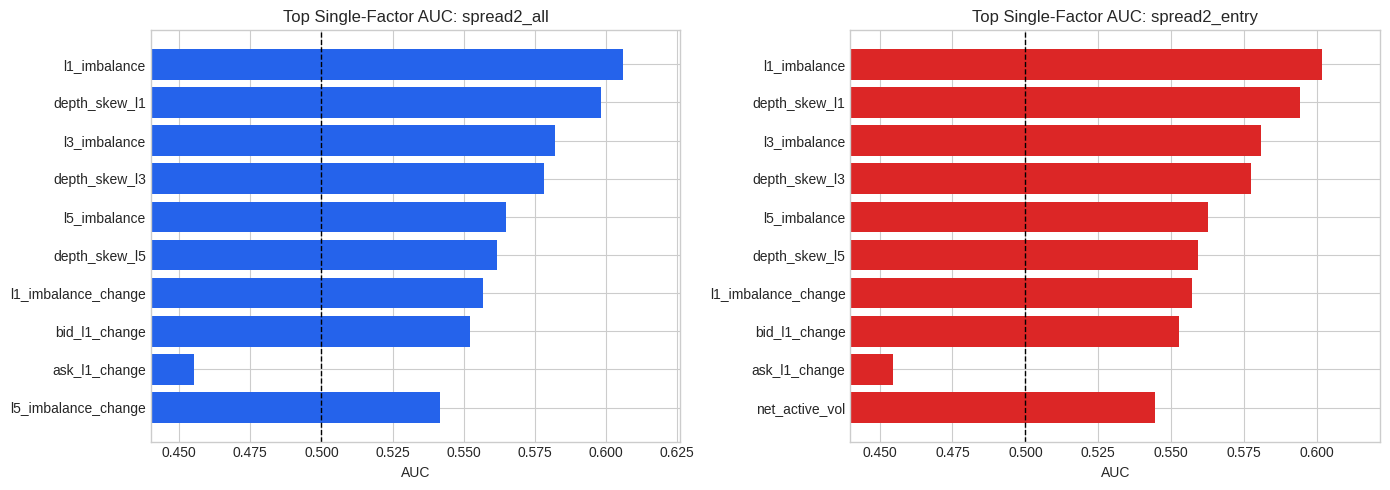

In [3]:
top_n = 12

display(Markdown('### `spread=2` 全样本 Top 因子'))
display(single_all.head(top_n))

display(Markdown('### `spread=2 entry` Top 因子'))
display(single_entry.head(top_n))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_all = single_all.head(10).iloc[::-1]
plot_entry = single_entry.head(10).iloc[::-1]

axes[0].barh(plot_all['feature'], plot_all['auc'], color='#2563eb')
axes[0].axvline(0.5, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Top Single-Factor AUC: spread2_all')
axes[0].set_xlabel('AUC')
axes[0].set_xlim(0.44, max(0.62, plot_all['auc'].max() + 0.02))

axes[1].barh(plot_entry['feature'], plot_entry['auc'], color='#dc2626')
axes[1].axvline(0.5, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Top Single-Factor AUC: spread2_entry')
axes[1].set_xlabel('AUC')
axes[1].set_xlim(0.44, max(0.62, plot_entry['auc'].max() + 0.02))

fig.tight_layout()
plt.show()


## 3. 组合模型系数

### Logit 系数: spread2_all

,feature,coef
0,l1_imbalance,0.2929
1,active_vol_imbalance,0.1767
2,net_active_vol,0.0727
3,depth_skew_l3,0.0706
4,l5_imbalance,0.0698
5,l5_imbalance_change,0.0557
6,l1_depth,0.0529
7,bid_l5_change,0.0487
8,l3_imbalance,0.0440
9,l3_imbalance_change,0.0190


### Logit 系数: spread2_entry

,feature,coef
0,l1_imbalance,0.2604
1,active_vol_imbalance,0.1774
2,net_active_vol,0.1708
3,l5_imbalance_change,0.1001
4,l3_imbalance,0.0799
5,bid_l5_change,0.0507
6,l1_depth,0.0474
7,depth_skew_l1,0.0461
8,depth_skew_l3,0.0420
9,l3_depth,0.0302


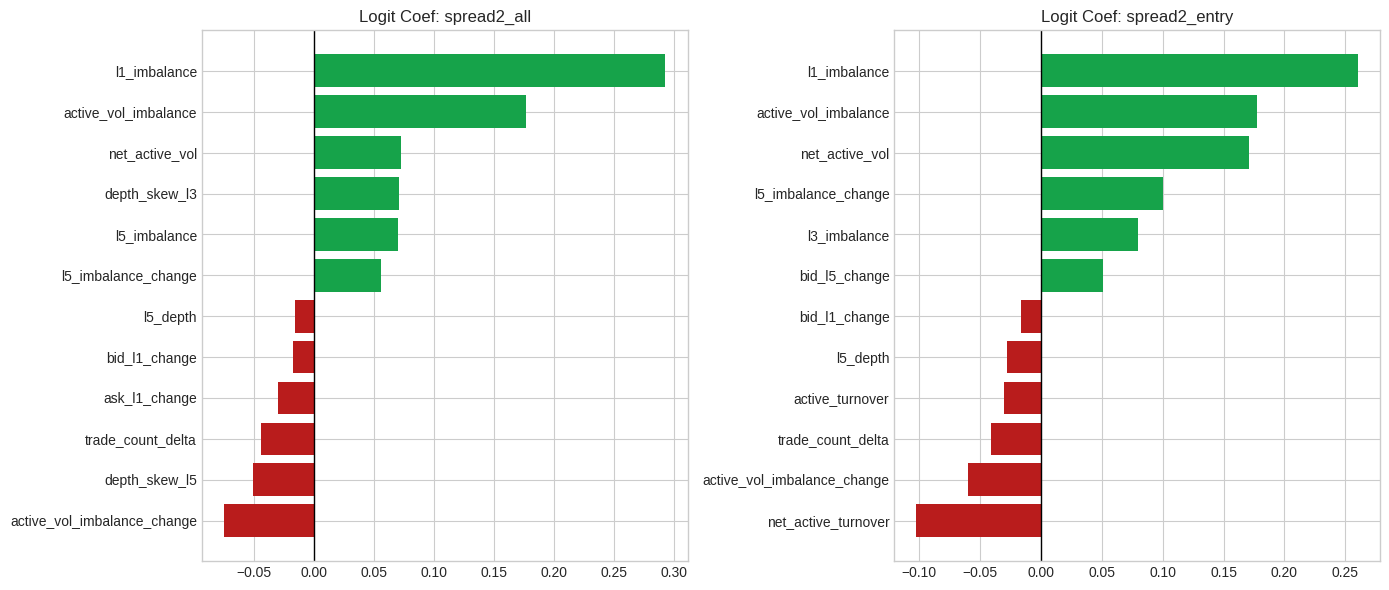

In [4]:
display(Markdown('### Logit 系数: spread2_all'))
display(coef_all.head(12))

display(Markdown('### Logit 系数: spread2_entry'))
display(coef_entry.head(12))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

coef_all_top = pd.concat([coef_all.head(6), coef_all.tail(6)]).sort_values('coef')
coef_entry_top = pd.concat([coef_entry.head(6), coef_entry.tail(6)]).sort_values('coef')

axes[0].barh(coef_all_top['feature'], coef_all_top['coef'], color=np.where(coef_all_top['coef'] >= 0, '#16a34a', '#b91c1c'))
axes[0].axvline(0.0, color='black', linewidth=1)
axes[0].set_title('Logit Coef: spread2_all')

axes[1].barh(coef_entry_top['feature'], coef_entry_top['coef'], color=np.where(coef_entry_top['coef'] >= 0, '#16a34a', '#b91c1c'))
axes[1].axvline(0.0, color='black', linewidth=1)
axes[1].set_title('Logit Coef: spread2_entry')

fig.tight_layout()
plt.show()


## 4. Imbalance 分桶与下一跳方向

### `l1_imbalance` 分桶表

,feature,bucket,samples,feature_mean,next_up_ratio,median_wait,label
0,l1_imbalance,"(-1.001, -0.796]",4559,-0.9126,0.3422,1.0000,NaN
1,l1_imbalance,"(-0.796, -0.575]",4559,-0.6834,0.4034,1.0000,NaN
2,l1_imbalance,"(-0.575, -0.371]",4559,-0.4700,0.4488,1.0000,NaN
3,l1_imbalance,"(-0.371, -0.183]",4558,-0.2764,0.4638,1.0000,NaN
4,l1_imbalance,"(-0.183, 0.00436]",4559,-0.0876,0.4942,1.0000,NaN
5,l1_imbalance,"(0.00436, 0.185]",4559,0.0936,0.5102,1.0000,NaN
6,l1_imbalance,"(0.185, 0.374]",4558,0.2794,0.5535,1.0000,NaN
7,l1_imbalance,"(0.374, 0.573]",4559,0.4730,0.5756,1.0000,NaN
8,l1_imbalance,"(0.573, 0.792]",4559,0.6800,0.6098,1.0000,NaN
9,l1_imbalance,"(0.792, 1.0]",4559,0.9072,0.6633,1.0000,NaN


### `l3_imbalance` 分桶表

,feature,bucket,samples,feature_mean,next_up_ratio,median_wait,label
10,l3_imbalance,"(-0.998, -0.494]",4559,-0.6590,0.3790,1.0000,NaN
11,l3_imbalance,"(-0.494, -0.317]",4559,-0.3998,0.4161,1.0000,NaN
12,l3_imbalance,"(-0.317, -0.191]",4559,-0.2511,0.4698,1.0000,NaN
13,l3_imbalance,"(-0.191, -0.0832]",4558,-0.1356,0.4770,1.0000,NaN
14,l3_imbalance,"(-0.0832, 0.014]",4559,-0.0350,0.5054,1.0000,NaN
15,l3_imbalance,"(0.014, 0.109]",4559,0.0619,0.5021,1.0000,NaN
16,l3_imbalance,"(0.109, 0.214]",4558,0.1601,0.5434,1.0000,NaN
17,l3_imbalance,"(0.214, 0.342]",4559,0.2754,0.5633,1.0000,NaN
18,l3_imbalance,"(0.342, 0.519]",4559,0.4247,0.5826,1.0000,NaN
19,l3_imbalance,"(0.519, 0.997]",4559,0.6723,0.6260,1.0000,NaN


### `l5_imbalance` 分桶表

,feature,bucket,samples,feature_mean,next_up_ratio,median_wait,label
20,l5_imbalance,"(-0.999, -0.362]",4559,-0.5200,0.3909,1.0000,NaN
21,l5_imbalance,"(-0.362, -0.225]",4559,-0.2856,0.4516,1.0000,NaN
22,l5_imbalance,"(-0.225, -0.134]",4559,-0.1783,0.4694,1.0000,NaN
23,l5_imbalance,"(-0.134, -0.0596]",4558,-0.0966,0.4958,1.0000,NaN
24,l5_imbalance,"(-0.0596, 0.0126]",4559,-0.0234,0.4973,1.0000,NaN
25,l5_imbalance,"(0.0126, 0.084]",4559,0.0481,0.5078,1.0000,NaN
26,l5_imbalance,"(0.084, 0.159]",4558,0.1208,0.5355,1.0000,NaN
27,l5_imbalance,"(0.159, 0.252]",4559,0.2031,0.5585,1.0000,NaN
28,l5_imbalance,"(0.252, 0.391]",4559,0.3146,0.5497,1.0000,NaN
29,l5_imbalance,"(0.391, 0.995]",4559,0.5393,0.6082,1.0000,NaN


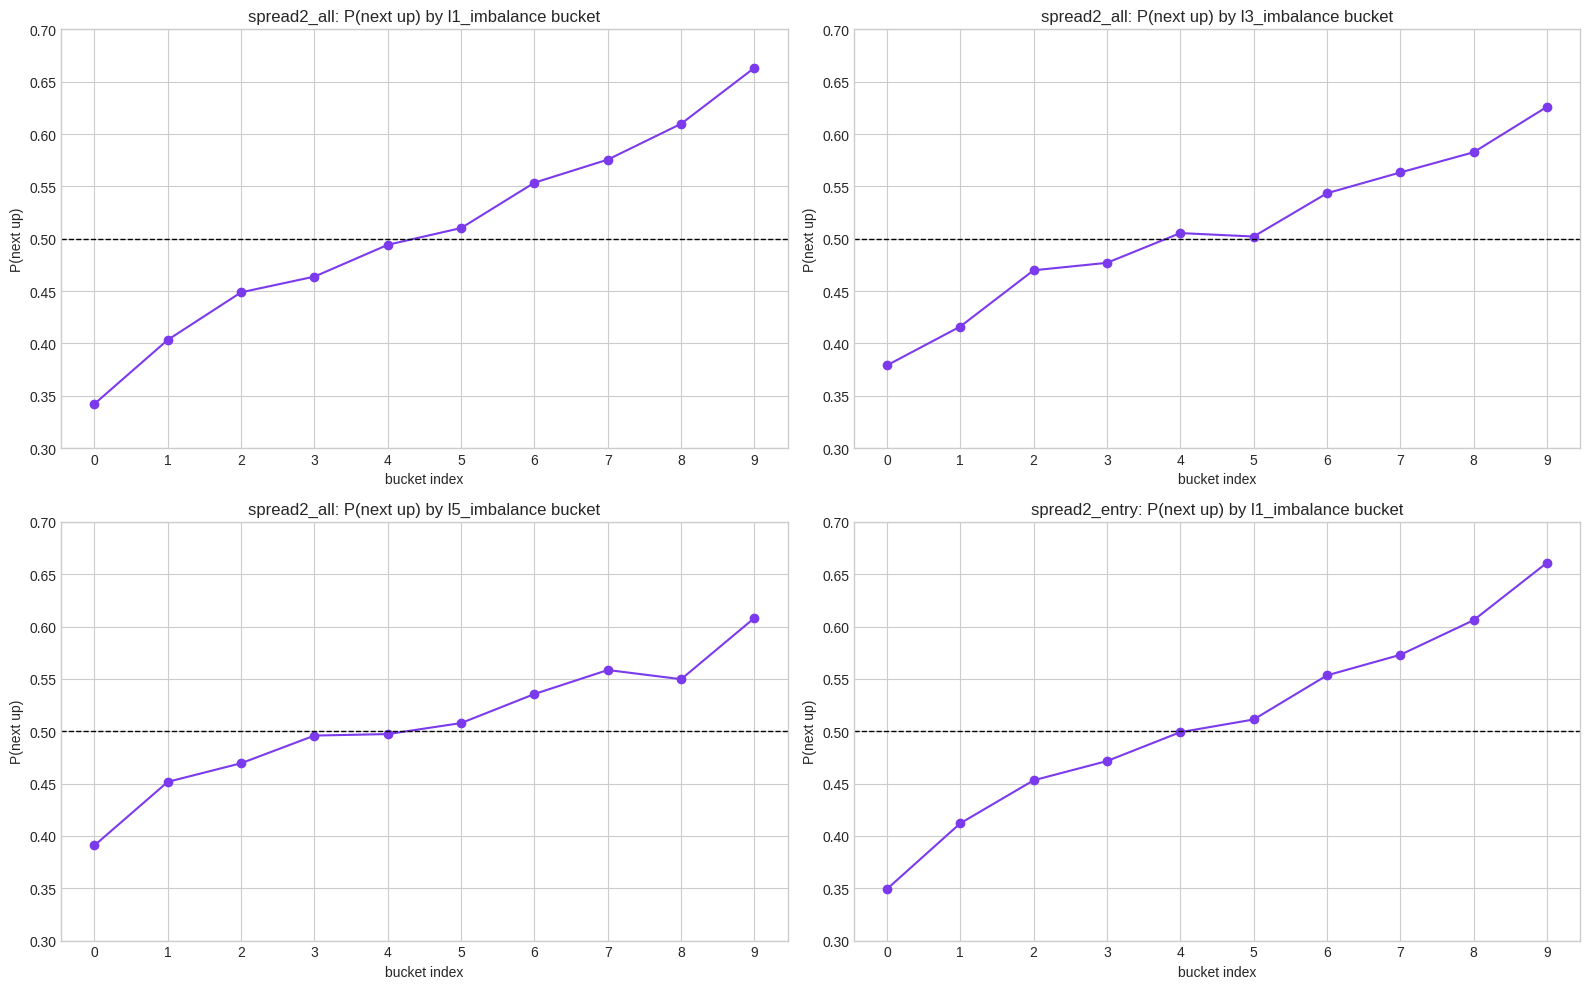

In [5]:
bucket_all = buckets[buckets['label'].isna()].copy()
bucket_entry = buckets[buckets['label'] == 'spread2_entry'].copy()

for feature in ['l1_imbalance', 'l3_imbalance', 'l5_imbalance']:
    display(Markdown(f'### `{feature}` 分桶表'))
    display(bucket_all.loc[bucket_all['feature'] == feature])

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
plots = [
    ('l1_imbalance', bucket_all, 'spread2_all'),
    ('l3_imbalance', bucket_all, 'spread2_all'),
    ('l5_imbalance', bucket_all, 'spread2_all'),
    ('l1_imbalance', bucket_entry, 'spread2_entry'),
]

for ax, (feature, df, label) in zip(axes.flat, plots):
    sdf = df.loc[df['feature'] == feature].reset_index(drop=True)
    ax.plot(range(len(sdf)), sdf['next_up_ratio'], marker='o', color='#7c3aed')
    ax.axhline(0.5, color='black', linestyle='--', linewidth=1)
    ax.set_title(f'{label}: P(next up) by {feature} bucket')
    ax.set_xlabel('bucket index')
    ax.set_ylabel('P(next up)')
    ax.set_xticks(range(len(sdf)))
    ax.set_ylim(0.30, 0.70)

fig.tight_layout()
plt.show()


## 5. 结论速记

In [6]:
l1_all = bucket_all.loc[bucket_all['feature'] == 'l1_imbalance'].reset_index(drop=True)
l1_entry = bucket_entry.loc[bucket_entry['feature'] == 'l1_imbalance'].reset_index(drop=True)

msg = f'''
### 读图结论

- `spread=2` 状态下，下一跳方向不是完全随机，样本外 AUC 在 `0.617 ~ 0.622`。
- 最稳定的单因子是 `l1_imbalance`，全样本单因子 AUC 为 `{single_all.iloc[0]["auc"]:.3f}`，entry 样本为 `{single_entry.iloc[0]["auc"]:.3f}`。
- `l1_imbalance` 从最空档到最多档，`P(next up)` 在全样本里从 `{l1_all.iloc[0]["next_up_ratio"]:.1%}` 升到 `{l1_all.iloc[-1]["next_up_ratio"]:.1%}`。
- 对 `spread2_entry` 子样本，这个梯度依然存在：`{l1_entry.iloc[0]["next_up_ratio"]:.1%}` -> `{l1_entry.iloc[-1]["next_up_ratio"]:.1%}`。
- 因此更合理的解读是：`spread=2` 不只意味着波动风险上升，也包含可被盘口失衡解释的方向性信息；但方向性强度是中等，不是压倒性的单边毒性。
'''

display(Markdown(msg))



### 读图结论

- `spread=2` 状态下，下一跳方向不是完全随机，样本外 AUC 在 `0.617 ~ 0.622`。
- 最稳定的单因子是 `l1_imbalance`，全样本单因子 AUC 为 `0.606`，entry 样本为 `0.602`。
- `l1_imbalance` 从最空档到最多档，`P(next up)` 在全样本里从 `34.2%` 升到 `66.3%`。
- 对 `spread2_entry` 子样本，这个梯度依然存在：`34.9%` -> `66.1%`。
- 因此更合理的解读是：`spread=2` 不只意味着波动风险上升，也包含可被盘口失衡解释的方向性信息；但方向性强度是中等，不是压倒性的单边毒性。
